In [1]:
!pip install pandas numpy matplotlib seaborn scipy statsmodels

!pip install statsforecast
!pip install mlforecast
!pip install neuralforecast

!pip install prophet
!pip install xgboost lightgbm scikit-learn

!pip install plotly

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Задача 1

# Подготовка

In [3]:
plt.style.use('default')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [4]:
train = pd.read_csv("DailyDelhiClimateTrain.csv")
test = pd.read_csv("DailyDelhiClimateTest.csv")

print(train.shape)
print(test.shape)

train.head()

(1462, 5)
(114, 5)


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [5]:
df = pd.concat([train, test], ignore_index=True)

df['date'] = pd.to_datetime(df['date'])

df = df.sort_values('date')
df = df.reset_index(drop=True)

df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [6]:
print(f'Размер датасета: {df.shape}')

print("\nТипы данных:")
print(df.dtypes)

print("\nПропуски:")
print(df.isna().sum())

Размер датасета: (1576, 5)

Типы данных:
date            datetime64[ns]
meantemp               float64
humidity               float64
wind_speed             float64
meanpressure           float64
dtype: object

Пропуски:
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64


# Первичный анализ временного ряда

In [7]:
print(df.describe())

                                date     meantemp     humidity   wind_speed  \
count                           1576  1576.000000  1576.000000  1576.000000   
mean   2015-02-27 10:15:50.253807104    25.221918    60.445229     6.899262   
min              2013-01-01 00:00:00     6.000000    13.428571     0.000000   
25%              2014-01-29 18:00:00    18.500000    49.750000     3.700000   
50%              2015-02-27 12:00:00    27.166667    62.440476     6.363571   
75%              2016-03-27 06:00:00    31.142857    72.125000     9.262500   
max              2017-04-24 00:00:00    38.714286   100.000000    42.220000   
std                              NaN     7.345014    16.979994     4.510725   

       meanpressure  
count   1576.000000  
mean    1010.593178  
min       -3.041667  
25%     1001.875000  
50%     1009.055556  
75%     1015.200000  
max     7679.333333  
std      175.242704  


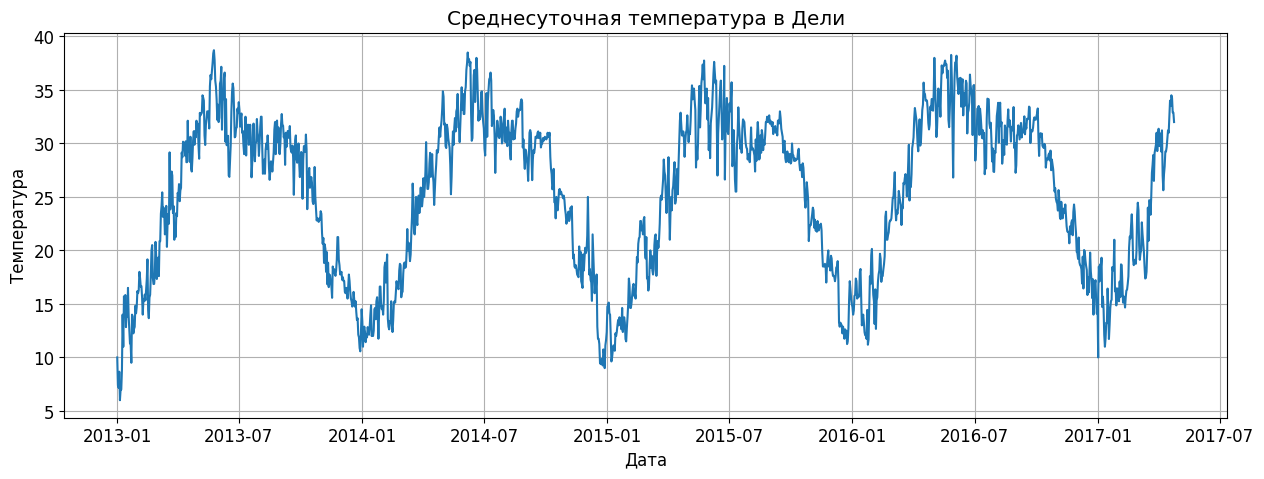

In [8]:
plt.figure(figsize=(15, 5))

plt.plot(df['date'], df['meantemp'])

plt.title('Среднесуточная температура в Дели')
plt.xlabel('Дата')
plt.ylabel('Температура')
plt.grid()

plt.show()

# EDA (Exploratory Data Analysis)

In [9]:
df.describe().T
for col in ['meantemp', 'humidity', 'wind_speed', 'meanpressure']:
    print(f'\n{col}')
    print(df[col].describe())


meantemp
count    1576.000000
mean       25.221918
std         7.345014
min         6.000000
25%        18.500000
50%        27.166667
75%        31.142857
max        38.714286
Name: meantemp, dtype: float64

humidity
count    1576.000000
mean       60.445229
std        16.979994
min        13.428571
25%        49.750000
50%        62.440476
75%        72.125000
max       100.000000
Name: humidity, dtype: float64

wind_speed
count    1576.000000
mean        6.899262
std         4.510725
min         0.000000
25%         3.700000
50%         6.363571
75%         9.262500
max        42.220000
Name: wind_speed, dtype: float64

meanpressure
count    1576.000000
mean     1010.593178
std       175.242704
min        -3.041667
25%      1001.875000
50%      1009.055556
75%      1015.200000
max      7679.333333
Name: meanpressure, dtype: float64


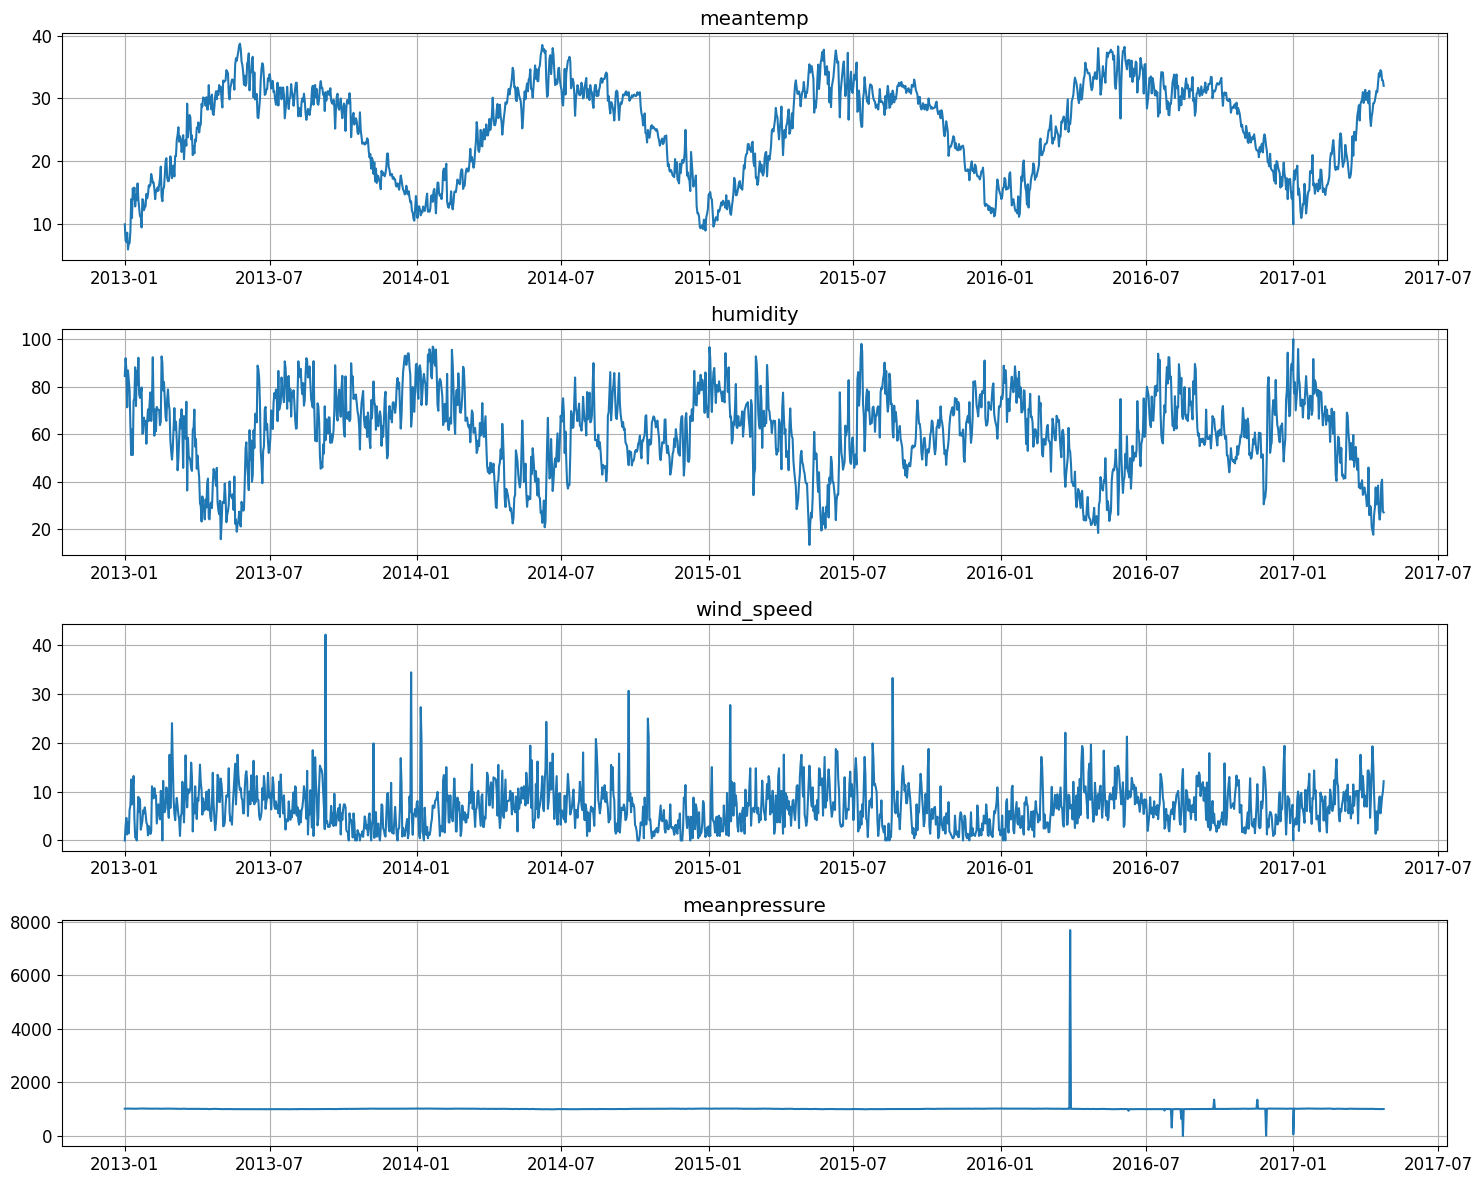

In [10]:
fig, axes = plt.subplots(4, 1, figsize=(15, 12))

columns = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']

for i, col in enumerate(columns):
    axes[i].plot(df['date'], df[col])
    axes[i].set_title(col)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [11]:
df[
    (df['meanpressure'] < 900) |
    (df['meanpressure'] > 1100)
][['date', 'meanpressure']]

,date,meanpressure
1182,2016-03-28,7679.333333
1309,2016-08-02,310.437500
1321,2016-08-14,633.900000
1323,2016-08-16,-3.041667
1362,2016-09-24,1352.615385
1416,2016-11-17,1350.296296
1427,2016-11-28,12.045455
1462,2017-01-01,59.000000


In [12]:
df.loc[
    (df['meanpressure'] < 900) |
    (df['meanpressure'] > 1100),
    'meanpressure'
] = np.nan

In [13]:
df['meanpressure'] = (
    df['meanpressure']
    .interpolate(method='linear')
)

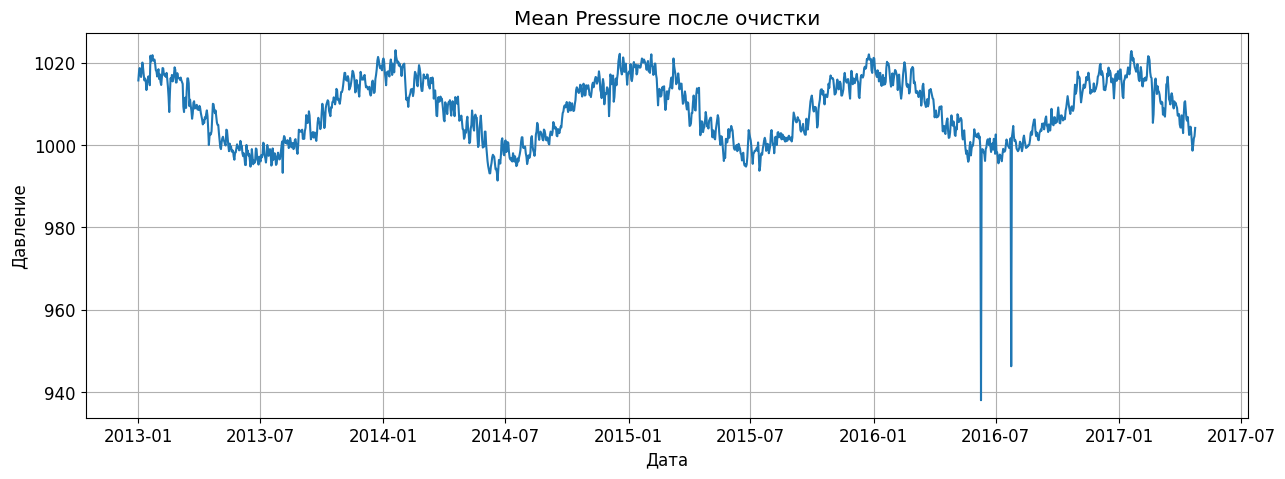

In [14]:
plt.figure(figsize=(15, 5))

plt.plot(
    df['date'],
    df['meanpressure']
)

plt.title('Mean Pressure после очистки')
plt.xlabel('Дата')
plt.ylabel('Давление')
plt.grid()

plt.show()

In [15]:
corr_df = df.drop(
    columns=['date', 'month', 'rolling30'],
    errors='ignore'
)

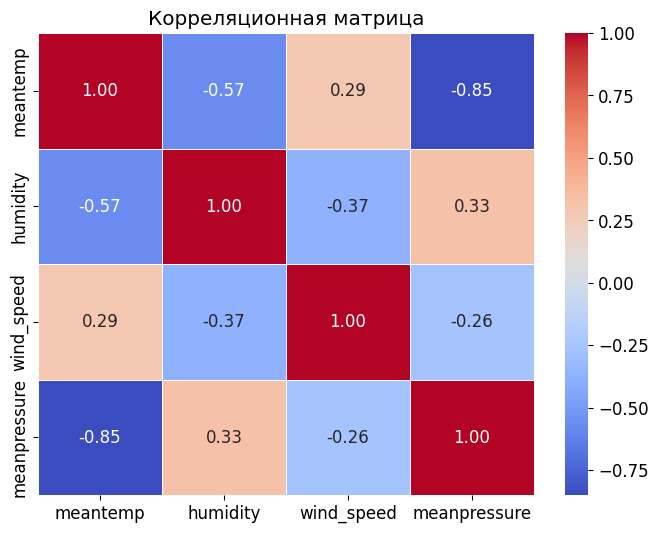

In [16]:
corr = corr_df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Корреляционная матрица')
plt.show()

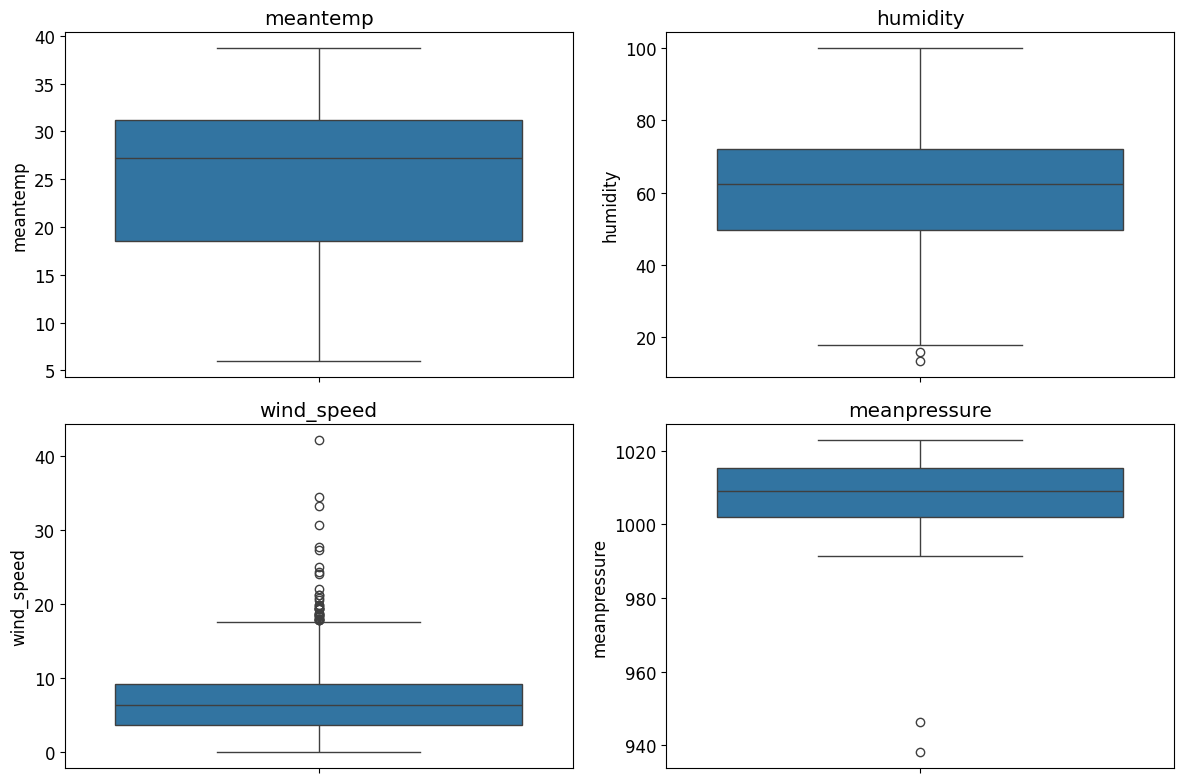

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

features = [
    'meantemp',
    'humidity',
    'wind_speed',
    'meanpressure'
]

for ax, feature in zip(axes.flatten(), features):

    sns.boxplot(
        y=df[feature],
        ax=ax
    )

    ax.set_title(feature)

plt.tight_layout()
plt.show()

In [18]:
df.sort_values(
    'wind_speed',
    ascending=False
).head(20)

,date,meantemp,humidity,wind_speed,meanpressure
251,2013-09-09,31.000000,57.500000,42.220000,1007.000000
358,2013-12-25,13.666667,63.166667,34.487500,1020.625000
960,2015-08-19,31.250000,61.250000,33.325000,1002.375000
630,2014-09-23,31.000000,47.000000,30.685714,1004.285714
757,2015-01-28,11.714286,67.000000,27.775000,1018.250000
370,2014-01-06,11.428571,86.285714,27.337500,1017.625000
654,2014-10-17,25.000000,47.666667,25.012500,1013.625000
527,2014-06-12,32.875000,39.250000,24.325000,997.000000
59,2013-03-01,17.333333,49.333333,24.066667,1016.333333
1176,2016-03-22,25.062500,37.875000,22.100000,1009.375000


In [19]:
Q1 = df['wind_speed'].quantile(0.25)
Q3 = df['wind_speed'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Нижняя граница:", lower)
print("Верхняя граница:", upper)

Нижняя граница: -4.643749999999998
Верхняя граница: 17.606249999999996


In [20]:
outliers = df[
    (df['wind_speed'] < lower) |
    (df['wind_speed'] > upper)
]

print("Количество выбросов:", len(outliers))

Количество выбросов: 33


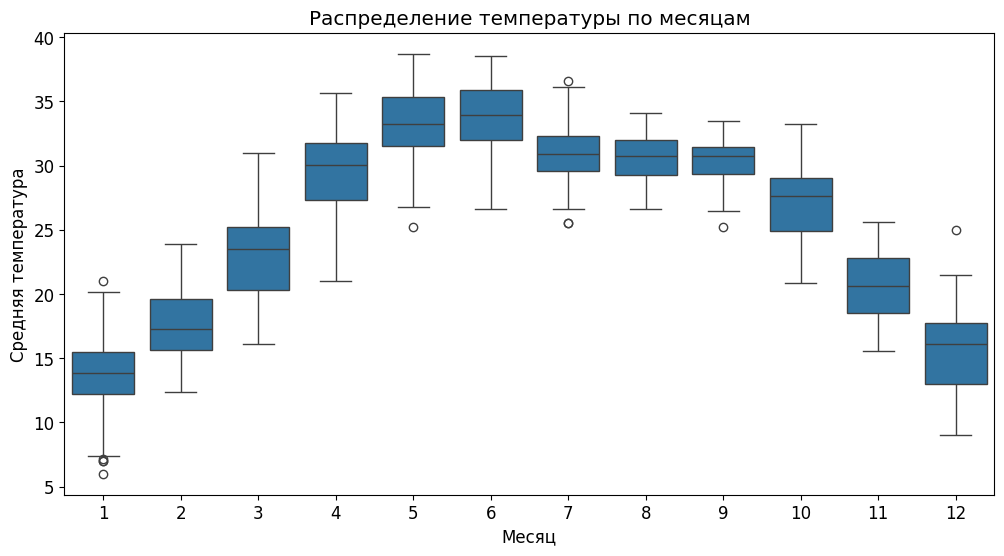

In [21]:
df['month'] = df['date'].dt.month

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='month',
    y='meantemp'
)

plt.title('Распределение температуры по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Средняя температура')

plt.show()

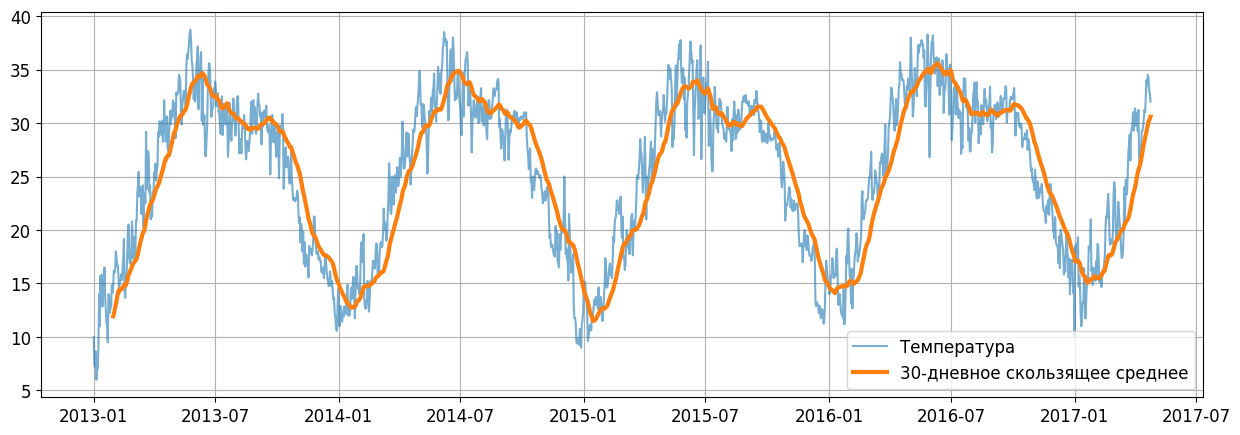

In [22]:
df['rolling30'] = df['meantemp'].rolling(30).mean()

plt.figure(figsize=(15, 5))

plt.plot(
    df['date'],
    df['meantemp'],
    alpha=0.6,
    label='Температура'
)

plt.plot(
    df['date'],
    df['rolling30'],
    linewidth=3,
    label='30-дневное скользящее среднее'
)

plt.legend()
plt.grid()

plt.show()

# Декомпозиция ряда

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [24]:
decomposition = seasonal_decompose(
    df['meantemp'],
    model='additive',
    period=365
)

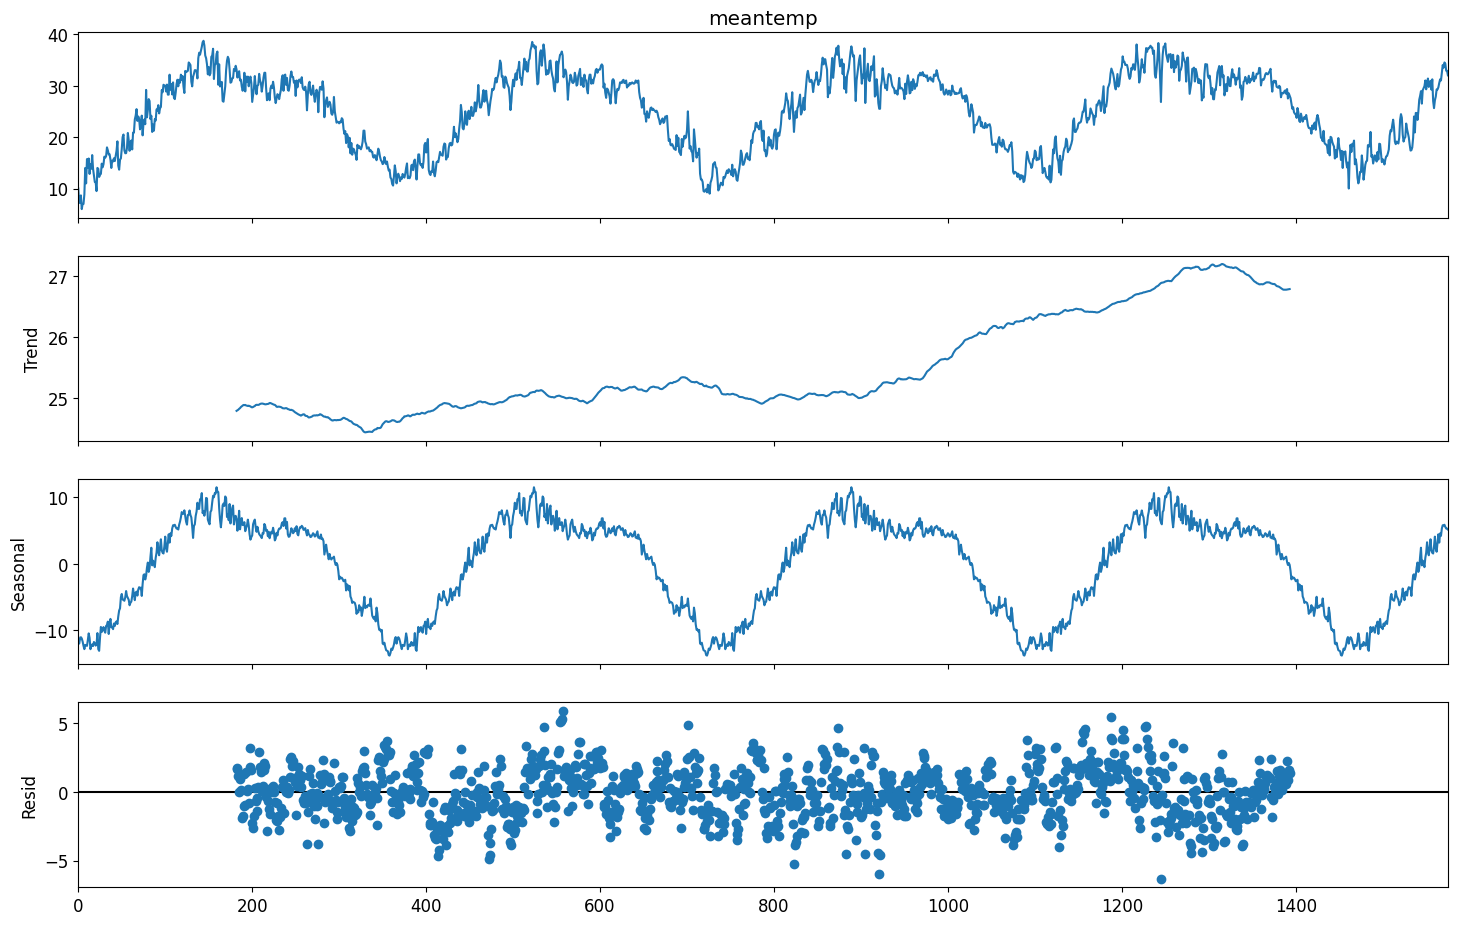

In [25]:
fig = decomposition.plot()

fig.set_size_inches(15, 10)

plt.show()

# Проверка стационарности (ADF-тест)

In [26]:
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(df['meantemp'])

In [27]:
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

for key, value in adf_result[4].items():
    print(f'Critical Value ({key}): {value}')

ADF Statistic: -2.3791899484520935
p-value: 0.14769623489792338
Critical Value (1%): -3.4345353407734733
Critical Value (5%): -2.86338857621683
Critical Value (10%): -2.567754150088293


In [28]:
if adf_result[1] < 0.05:
    print("Ряд стационарен")
else:
    print("Ряд нестационарен")

Ряд нестационарен


# ACF (автокорреляция)

<Figure size 1200x500 with 0 Axes>

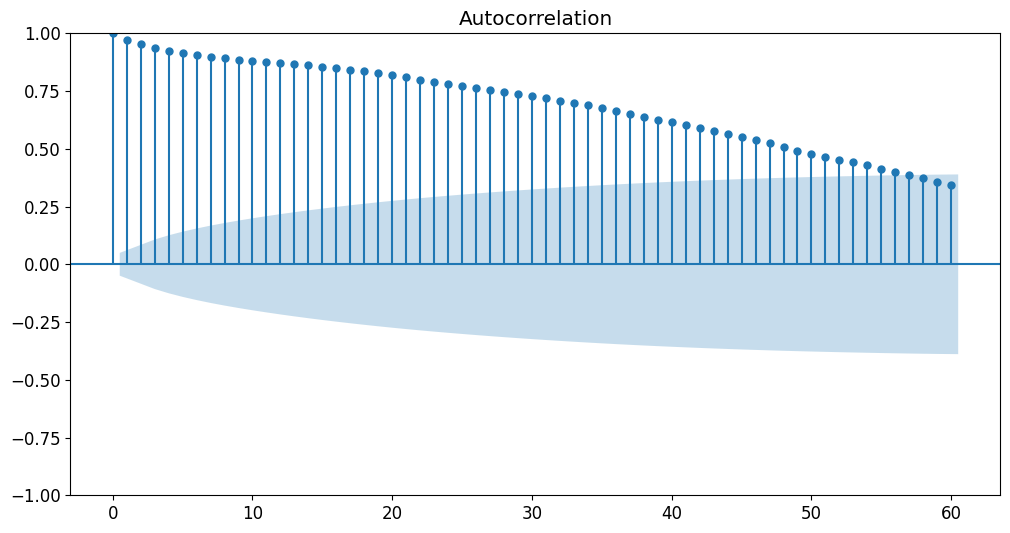

In [29]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12,5))

plot_acf(
    df['meantemp'],
    lags=60
)

plt.show()

# PACF (частичная автокорреляция)

<Figure size 1200x500 with 0 Axes>

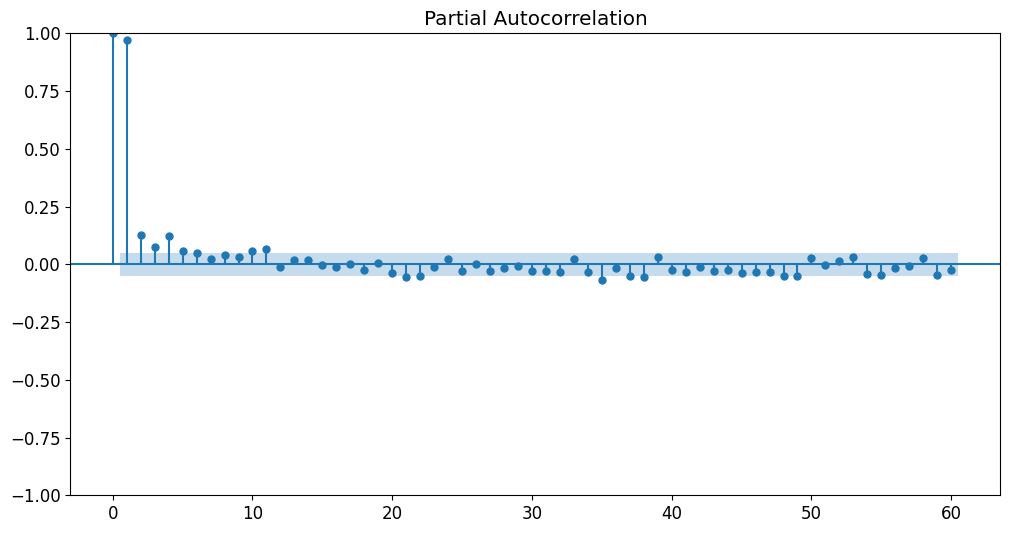

In [30]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(12,5))

plot_pacf(
    df['meantemp'],
    lags=60,
    method='ywm'
)

plt.show()

# Поиск аномалий по температуре через Z-score

In [31]:
from scipy import stats

z_scores = np.abs(
    stats.zscore(df['meantemp'])
)

anomalies = df[z_scores > 3]

print(
    f'Количество аномалий: {len(anomalies)}'
)

Количество аномалий: 0


# Визуализация аномалий

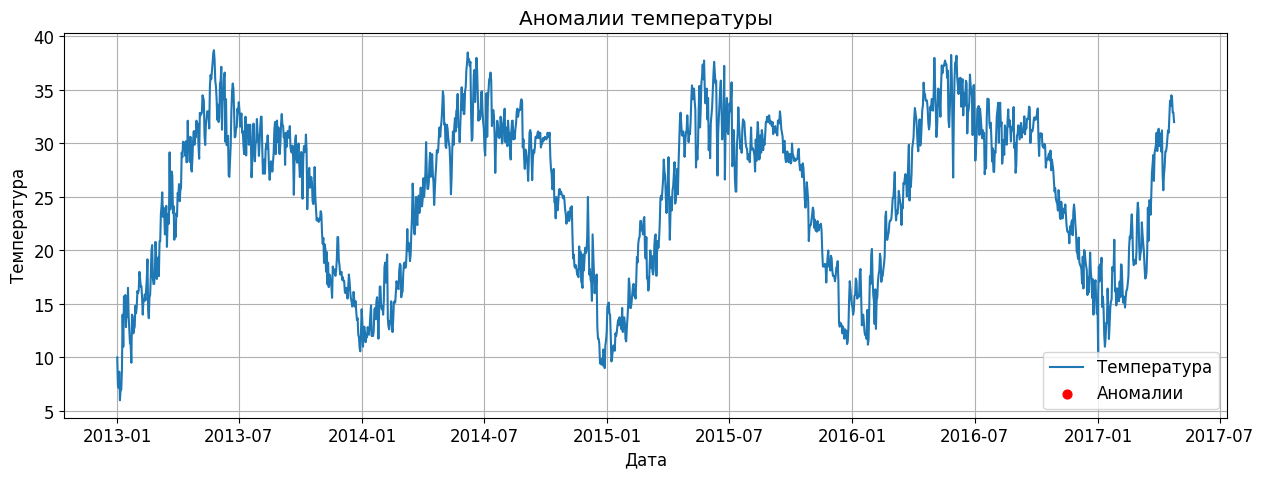

In [32]:
plt.figure(figsize=(15,5))

plt.plot(
    df['date'],
    df['meantemp'],
    label='Температура'
)

plt.scatter(
    anomalies['date'],
    anomalies['meantemp'],
    color='red',
    s=40,
    label='Аномалии'
)

plt.title('Аномалии температуры')
plt.xlabel('Дата')
plt.ylabel('Температура')

plt.legend()
plt.grid()

plt.show()

In [33]:
df.to_csv(
    'prepared_weather.csv',
    index=False
)

In [34]:
adf_result = adfuller(df['meantemp'])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -2.3791899484520935
p-value: 0.14769623489792338


# Задача 2

# Подготовка данных под StatsForecast

In [35]:
forecast_df = df[['date', 'meantemp']].copy()

forecast_df.columns = ['ds', 'y']

forecast_df['unique_id'] = 'Delhi'

forecast_df = forecast_df[
    ['unique_id', 'ds', 'y']
]

forecast_df.head()

,unique_id,ds,y
0,Delhi,2013-01-01,10.000000
1,Delhi,2013-01-02,7.400000
2,Delhi,2013-01-03,7.166667
3,Delhi,2013-01-04,8.666667
4,Delhi,2013-01-05,6.000000


In [36]:
h = 30

train = forecast_df[:-h]
test = forecast_df[-h:]

print(train.shape)
print(test.shape)

(1546, 3)
(30, 3)


# Импорт и создание моделей

In [37]:
from statsforecast import StatsForecast

from statsforecast.models import (
    Naive,
    SeasonalNaive,
    AutoARIMA,
    AutoETS,
    AutoTheta
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

models = [
    Naive(),
    SeasonalNaive(season_length=7),
    AutoARIMA(season_length=7),
    AutoETS(season_length=7),
    AutoTheta(season_length=7)
]

# Обучение моделей

In [38]:
sf = StatsForecast(
    models=models,
    freq='D',
    n_jobs=1
)

predictions = sf.forecast(
    df=train,
    h=h
)

# Метрики

In [39]:
results = []

for model in predictions.columns[1:]:

    mae = mean_absolute_error(
        test['y'],
        predictions[model]
    )

    rmse = np.sqrt(
        mean_squared_error(
            test['y'],
            predictions[model]
        )
    )

    results.append(
        [model, mae, rmse]
    )

# Таблица сравнения

In [40]:
results_df = pd.DataFrame(
    results,
    columns=['Model', 'MAE', 'RMSE']
)

results_df = results_df.sort_values(
    'RMSE'
)

results_df

,Model,MAE,RMSE
5,AutoTheta,3.445666e+00,3.963056e+00
4,AutoETS,3.713469e+00,4.206398e+00
3,AutoARIMA,4.077710e+00,4.598309e+00
1,Naive,4.141251e+00,4.607214e+00
2,SeasonalNaive,4.680139e+00,5.261984e+00
0,ds,1.491739e+18,1.491739e+18


# График прогнозов

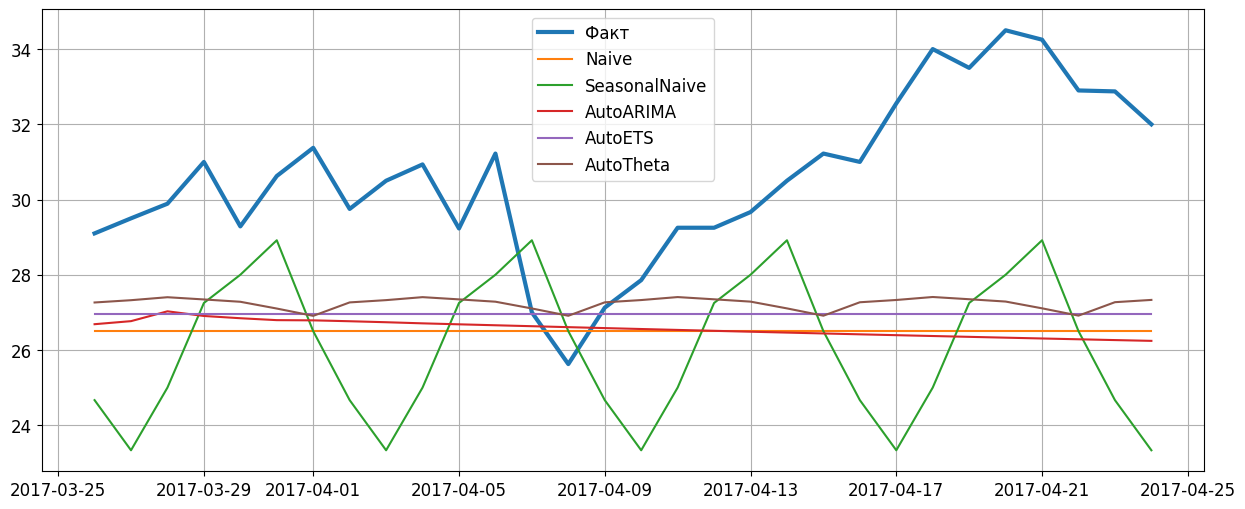

In [42]:
forecast_models = [
    'Naive',
    'SeasonalNaive',
    'AutoARIMA',
    'AutoETS',
    'AutoTheta'
]

plt.figure(figsize=(15,6))

plt.plot(
    test['ds'],
    test['y'],
    label='Факт',
    linewidth=3
)

for model in forecast_models:

    plt.plot(
        test['ds'],
        predictions[model],
        label=model
    )

plt.legend()
plt.grid()
plt.show()

# Выбор лучшей модели

In [43]:
best_model = results_df.iloc[0]

print(best_model)

Model    AutoTheta
MAE       3.445666
RMSE      3.963056
Name: 5, dtype: object


# Задача №3. MLForecast и NeuralForecast

In [44]:
!pip install mlforecast
!pip install neuralforecast
!pip install xgboost
!pip install lightgbm

# Подготовка данных

In [45]:
ml_df = df[['date', 'meantemp']].copy()

ml_df.columns = ['ds', 'y']

ml_df['unique_id'] = 'Delhi'

ml_df.head()

,ds,y,unique_id
0,2013-01-01,10.000000,Delhi
1,2013-01-02,7.400000,Delhi
2,2013-01-03,7.166667,Delhi
3,2013-01-04,8.666667,Delhi
4,2013-01-05,6.000000,Delhi


# Feature Engineering. ML-модели

In [47]:
from mlforecast import MLForecast
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

#Настройка MLForecast
models = {
    'RF': RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),

    'XGB': XGBRegressor(
        n_estimators=200,
        random_state=42
    ),

    'LGBM': LGBMRegressor(
        n_estimators=200,
        random_state=42
    )
}



In [49]:
# Подготовка данных

ml_df = df[['date', 'meantemp']].copy()

# календарные признаки
ml_df['month'] = ml_df['date'].dt.month
ml_df['dayofweek'] = ml_df['date'].dt.dayofweek
ml_df['dayofyear'] = ml_df['date'].dt.dayofyear

# лаги
ml_df['lag_1'] = ml_df['meantemp'].shift(1)
ml_df['lag_7'] = ml_df['meantemp'].shift(7)
ml_df['lag_30'] = ml_df['meantemp'].shift(30)

# скользящие средние
ml_df['roll_7'] = ml_df['meantemp'].shift(1).rolling(7).mean()
ml_df['roll_30'] = ml_df['meantemp'].shift(1).rolling(30).mean()

ml_df = ml_df.dropna()

# Разделение по времени

In [50]:
features = [
    'month',
    'dayofweek',
    'dayofyear',
    'lag_1',
    'lag_7',
    'lag_30',
    'roll_7',
    'roll_30'
]

X = ml_df[features]
y = ml_df['meantemp']

split = int(len(ml_df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

# Обучение сразу всех трех моделей

In [51]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

models = {
    'RandomForest': RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),

    'XGBoost': XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        random_state=42
    ),

    'LightGBM': LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    )
}

# Оценка

In [52]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    results.append(
        [name, mae, rmse]
    )

results_ml = pd.DataFrame(
    results,
    columns=['Model', 'MAE', 'RMSE']
)

results_ml.sort_values('RMSE')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000355 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1546
[LightGBM] [Info] Number of data points in the train set: 1236, number of used features: 8
[LightGBM] [Info] Start training from score 25.511600


,Model,MAE,RMSE
0,RandomForest,1.241423,1.635748
1,XGBoost,1.336139,1.687222
2,LightGBM,1.315685,1.687484


# Задача 4.

In [53]:
def preprocess(df):

    data = df.copy()

    data['month'] = data['date'].dt.month
    data['dayofweek'] = data['date'].dt.dayofweek
    data['dayofyear'] = data['date'].dt.dayofyear

    data['lag_1'] = data['meantemp'].shift(1)
    data['lag_7'] = data['meantemp'].shift(7)
    data['lag_30'] = data['meantemp'].shift(30)

    data['roll_7'] = (
        data['meantemp']
        .shift(1)
        .rolling(7)
        .mean()
    )

    data['roll_30'] = (
        data['meantemp']
        .shift(1)
        .rolling(30)
        .mean()
    )

    return data.dropna()

# Тестирование производительности

In [55]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

import time
import pandas as pd

times = []

for name, model in [
    ('RandomForest', rf),
    ('XGBoost', xgb),
    ('LightGBM', lgbm)
]:

    start = time.time()

    model.fit(X_train, y_train)

    elapsed = time.time() - start

    times.append([name, elapsed])

performance = pd.DataFrame(
    times,
    columns=['Model', 'Training Time (sec)']
)

performance

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000089 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1546
[LightGBM] [Info] Number of data points in the train set: 1236, number of used features: 8
[LightGBM] [Info] Start training from score 25.511600


,Model,Training Time (sec)
0,RandomForest,6.011565
1,XGBoost,0.402366
2,LightGBM,0.201997
